In [2]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt, os

### load dfs/csvs

In [15]:
data_dir = '../data/csvs'

df_all_clean_data = pd.read_parquet(f'{data_dir}/df_all_clean_data.parquet')
df_spikes = pd.read_parquet(f'{data_dir}/df_spikes.parquet')  # shape: (n_neurons, n_timebins), values = FR in Hz
valid_mask = np.load(f'{data_dir}/valid_mask.npy')            # shape: (n_neurons, n_timebins), bool
time_bins = np.load(f'{data_dir}/time_bins.npy')              # 1D array of bin start times in seconds

print(f"df_spikes:  {df_spikes.shape}")
print(f"valid_mask: {valid_mask.shape}")
print(f"time_bins:  {time_bins.shape}, from {time_bins[0]:.1f}s to {time_bins[-1]:.1f}s with step {time_bins[1]-time_bins[0]:.1f}s")

df_all_clean_data[['region', 'neur_id', 'enc_firing_rate']]

df_spikes:  (1123, 479)
valid_mask: (1123, 479)
time_bins:  (479,), from 0.0s to 478.0s with step 1.0s


,region,neur_id,enc_firing_rate
3,ACC,P58CS_R1_34_4_3301_5,17.235694
4,ACC,P58CS_R1_34_3_3299_5,1.456007
5,ACC,P58CS_R1_34_2_3239_5,1.845113
6,ACC,P58CS_R1_34_1_3232_5,0.518807
8,ACC,P58CS_R1_36_2_962_5,0.861889
...,...,...,...
1452,preSMA,P62CS_R1_18_3_3847_7,2.376471
1453,preSMA,P62CS_R1_18_2_3846_7,5.150416
1454,preSMA,P62CS_R1_18_1_3830_7,0.956028
1455,vmPFC,P62CS_R1_7_1_791_9,1.089913


### single-units

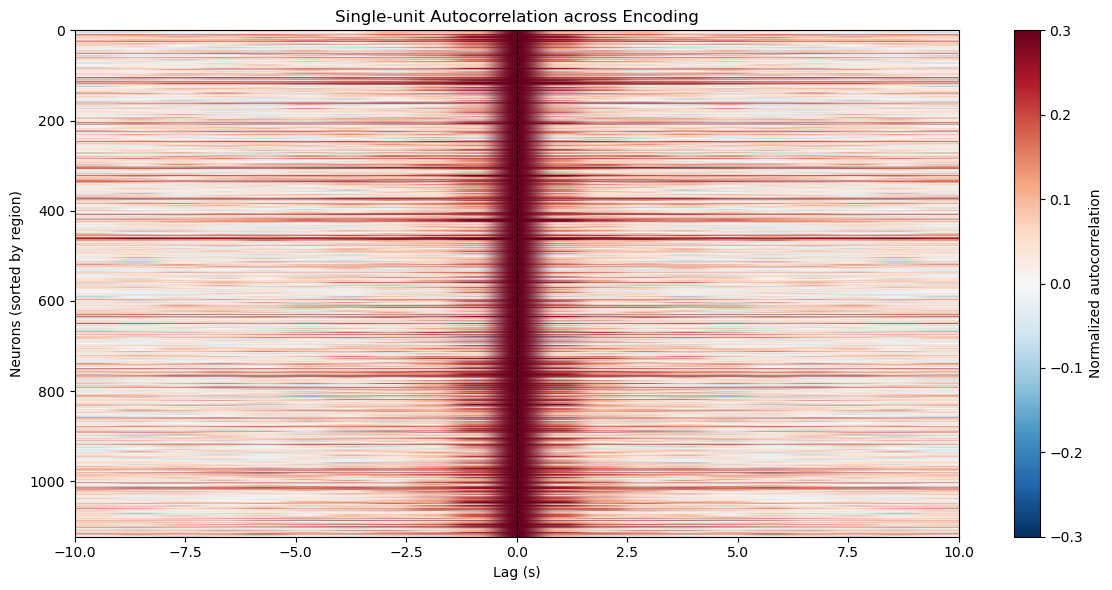

In [16]:
spike_matrix = df_spikes.values.copy().astype(float)

# z-score each neuron's FR timeseries so autocorrelations are comparable across neurons
spike_matrix[~valid_mask] = np.nan  # blank out gap bins before z-scoring
means = np.nanmean(spike_matrix, axis=1, keepdims=True)
stds  = np.nanstd(spike_matrix,  axis=1, keepdims=True)
z = (spike_matrix - means) / np.where(stds > 0, stds, 1)
z[~valid_mask] = 0  # treat gap bins as zero-mean after z-scoring (neutral for autocorr)

# compute normalized autocorrelation for each neuron
max_lag = 10  # seconds (= bins at 1s resolution)
n_neurons = z.shape[0]
autocorrs = np.zeros((n_neurons, 2 * max_lag + 1))

for i in range(n_neurons):
    full = np.correlate(z[i], z[i], mode='full')  # length 2*T-1
    mid = len(full) // 2
    autocorrs[i] = full[mid - max_lag : mid + max_lag + 1]
    autocorrs[i] /= autocorrs[i, max_lag]  # normalize to 1 at lag=0

lags = np.arange(-max_lag, max_lag + 1)  # in seconds

# sort rows by region for readability
sort_order = df_all_clean_data['region'].argsort().values
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(autocorrs[sort_order], aspect='auto', cmap='RdBu_r', vmin=-0.3, vmax=0.3,
               extent=[lags[0], lags[-1], len(sort_order), 0])
ax.axvline(0, color='k', linewidth=0.8, linestyle='--')
ax.set(xlabel='Lag (s)', ylabel='Neurons (sorted by region)',
       title='Single-unit Autocorrelation across Encoding')
plt.colorbar(im, ax=ax, label='Normalized autocorrelation')
plt.tight_layout()
plt.show()

### population

In [ ]:
pop_df = pd.DataFrame(autocorrs, columns=lags)
# plot population average autocorrelation with SEM shading
pop_mean = pop_df.mean()